In [1]:
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer
import warnings
warnings.filterwarnings("ignore")
import evaluate
import numpy as np
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
train_df = pd.read_csv("C://Users//User//Desktop//titles_data.csv", delimiter=';', skiprows=0, low_memory=False)
train_df=train_df.reset_index(drop=True)
train_df=train_df.rename(columns={"titles": "text", "target": "label"})
train_df

,text,label
0,Родственник раскрыл настоящую фамилию Пугачёво...,1
1,Предсказания Матроны Московской на 2024-й год:...,1
2,"Пророчество схимонахини Нины об антихристе, ми...",1
3,«Думал об этом»: что Путин сказал о своем прее...,1
4,Путин поручил уведомить россиян об изменениях ...,1
...,...,...
3193,Путин поручил передать Республике Крым все акц...,0
3194,ЕК изучит просьбу Венгрии по нарушению Болгари...,0
3195,"Глава ""Россетей"" доложил Путину о достижении ц...",0
3196,"Платформа ""Мой экспорт"" научит устанавливать д...",0


In [3]:
ds = Dataset.from_pandas(train_df)
ds

Dataset({
    features: ['text', 'label'],
    num_rows: 3198
})

In [2]:
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2") 

In [3]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

In [6]:
tokenized_ds = ds.map(preprocess_function, batched=True)

Map:   0%|          | 0/3198 [00:00<?, ? examples/s]

In [7]:
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
f1 = evaluate.load("f1")

In [4]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    d = {
        **accuracy.compute(predictions=predictions, references=labels),
        **precision.compute(predictions=predictions, references=labels),
        **f1.compute(predictions=predictions, references=labels)
    }
    return d

In [9]:
id2label = {0: "не кликбейт", 1: "кликбейт"}
label2id = {"не кликбейт": 0, "кликбейт": 1}

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny2", num_labels=2, id2label=id2label, label2id=label2id
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
split = tokenized_ds.train_test_split(test_size = 0.2)

In [13]:
training_args = TrainingArguments(
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    remove_unused_columns=True,
    load_best_model_at_end=True,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=split['train'],
    eval_dataset=split['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,F1
1,0.654800,0.355897,0.864062,0.905882,0.841530
2,0.269900,0.210721,0.917188,0.897690,0.911223
3,0.174000,0.188360,0.925000,0.921233,0.918089
4,0.101600,0.190752,0.935937,0.906752,0.932231
5,0.056800,0.187803,0.940625,0.929530,0.935811
6,0.041500,0.204522,0.945312,0.919094,0.941957
7,0.033300,0.238379,0.935937,0.899054,0.932897
8,0.019300,0.240201,0.937500,0.904459,0.934211
9,0.020700,0.240369,0.942187,0.913183,0.938843
10,0.022400,0.237390,0.940625,0.915584,0.936877


TrainOutput(global_step=800, training_loss=0.13010873414576055, metrics={'train_runtime': 45.9323, 'train_samples_per_second': 556.906, 'train_steps_per_second': 17.417, 'total_flos': 8296357319448.0, 'train_loss': 0.13010873414576055, 'epoch': 10.0})

In [12]:
#увеличенные батчи
training_args = TrainingArguments(
    learning_rate=5e-5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    num_train_epochs=10,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    remove_unused_columns=True,
    load_best_model_at_end=True,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=split['train'],
    eval_dataset=split['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,F1
1,No log,0.678252,0.682813,0.680000,0.685271
2,No log,0.625366,0.820312,0.811550,0.822804
3,0.658200,0.458927,0.862500,0.871795,0.860759
4,0.658200,0.314649,0.875000,0.863636,0.876923
5,0.343400,0.226963,0.914062,0.912773,0.914197
6,0.343400,0.201811,0.923438,0.927445,0.923077
7,0.343400,0.199143,0.926562,0.930599,0.926217
8,0.127900,0.205207,0.932813,0.926154,0.933333
9,0.127900,0.207806,0.929688,0.915408,0.930876
10,0.073200,0.203866,0.934375,0.926380,0.934985


TrainOutput(global_step=200, training_loss=0.3006850290298462, metrics={'train_runtime': 28.4563, 'train_samples_per_second': 898.923, 'train_steps_per_second': 7.028, 'total_flos': 9181146934584.0, 'train_loss': 0.3006850290298462, 'epoch': 10.0})

In [13]:
trainer.evaluate(split['test'])

{'eval_loss': 0.19914335012435913,
 'eval_accuracy': 0.9265625,
 'eval_precision': 0.9305993690851735,
 'eval_f1': 0.9262166405023547,
 'eval_runtime': 0.4257,
 'eval_samples_per_second': 1503.475,
 'eval_steps_per_second': 11.746,
 'epoch': 10.0}

# Многоклассовая классификация

In [4]:
df = pd.read_csv("C:\\Users\\User\\Desktop\\lenta_ru_news_2019_2023.csv")
df

,url,title,text,topic,tags,date
0,https://lenta.ru/news/2019/12/15/prsm/,Россиянам дали советы по выбору чая,Россиянам дали советы при выборе чая. Рекоменд...,Россия,Общество,2019-12-15
1,https://lenta.ru/news/2019/12/15/fb/,В Госдуме назвали японское заявление о Курилах...,Спикер Госдумы Вячеслав Володин назвал угрозой...,Россия,Политика,2019-12-15
2,https://lenta.ru/news/2019/12/15/kino/,Украинская ЛГБТ-активистка обвинила ню-фотогра...,Украинская ЛГБТ-активистка Виктория Гуйвик обв...,Культура,Фотография,2019-12-15
3,https://lenta.ru/news/2019/12/15/alba/,Полицейские застрелили порезавшего мать буйног...,В Москве полицейские застрелили мужчину при по...,Силовые структуры,Криминал,2019-12-15
4,https://lenta.ru/news/2019/12/15/anons/,Беглого президента Боливии решили арестовать,Исполняющая обязанности президента Боливии Жан...,Мир,Политика,2019-12-15
...,...,...,...,...,...,...
496252,https://lenta.ru/news/2024/01/01/braziliya-pri...,Пушилин сообщил о раненых в результате обстрел...,Глава Донецкой народной республики (ДНР) Денис...,Бывший СССР,Украина,2024-01-01
496253,https://lenta.ru/news/2024/01/01/eks-glava-mid...,В России подняли призывной возраст до 30 лет,С 1 января 2024 года начал действовать закон о...,Россия,Политика,2024-01-01
496254,https://lenta.ru/news/2024/01/01/na-ukraine-vy...,В России изменились условия выдачи материнског...,С 1 января 2024 года материнский капитал будут...,Россия,Политика,2024-01-01
496255,https://lenta.ru/news/2024/01/01/pushilin-soob...,На Украине высказались о возможной смене власти,Директор Украинского института анализа и менед...,Бывший СССР,Украина,2024-01-01


In [5]:
lenta_topics = {
    "Россия": 0,
    "Экономика": 1,
    "Силовые структуры": 2,
    "Бывший СССР": 3,
    "Спорт": 4,
    "Забота о себе": 5,
    "Здоровье": 5,
    "Строительство": 6,
    "Путешествия": 7,
    "Наука и техника": 8,
    "Интернет и СМИ": 0,
    "Бизнес": 1,
    }

In [6]:
df["number"] = df["topic"].apply(lambda x: lenta_topics[x] if x in lenta_topics else None)
df = df.dropna(subset=['number'])
df = df.dropna(subset=['text'])

df["number"] = df["number"].apply(lambda x: int(x))

In [7]:
df.columns = ['url','title','text','topic','tags','date','label']

In [8]:
df['label'].value_counts()

label
0    118456
3     51071
1     49015
2     30249
4     28442
8     25209
7     19308
5      7589
Name: count, dtype: int64

In [9]:
n_samples = 3000
random_state = 42  # фиксируем для воспроизводимости

# функция для группового отбора
def sample_per_class(group):
    if len(group) < n_samples:
        raise ValueError(f"В классе {group.name} всего {len(group)} примеров, меньше {n_samples}")
    return group.sample(n=n_samples, random_state=random_state)

# применяем к каждой группе по столбцу 'number'
balanced_df = (
    df
    .groupby('label', group_keys=False)  # group_keys=False, чтобы сразу получить DataFrame
    .apply(sample_per_class)
    .reset_index(drop=True)
)

balanced_df['label'].value_counts()

label
0    3000
1    3000
2    3000
3    3000
4    3000
5    3000
7    3000
8    3000
Name: count, dtype: int64

In [25]:
def get_unique_texts(df1: pd.DataFrame, df2: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    """
    Возвращает до n строк из df1, у которых значения в колонке 'text'
    отсутствуют в колонке 'text' df2 и при этом каждая строка имеет уникальный 'label'.
    """
    # 1. Отфильтровать по отсутствию текста в df2
    texts_in_df2 = set(df2['text'])
    df_diff = df1[~df1['text'].isin(texts_in_df2)].copy()
    
    # 2. Для каждого класса (label) взять по одной строке
    #    Если у класса несколько таких строк, берём первую
    df_unique_labels = (
        df_diff
        .sort_values('text')            # упорядочиваем, чтобы deterministic выбор, по желанию можно убрать
        .groupby('label', as_index=False)
        .first()                        # берёт первую строку в каждой группе
    )
    
    # 3. Взять первые n строк из получившегося датафрейма
    return df_unique_labels.head(n)

In [30]:
unique_rows = get_unique_texts(df, balanced_df, n=9)

In [12]:
new_ds = Dataset.from_pandas(balanced_df)
new_ds

Dataset({
    features: ['url', 'title', 'text', 'topic', 'tags', 'date', 'label'],
    num_rows: 24000
})

In [13]:
id2label = {
    0: "Россия", 
    1: "Экономика",
    2: "Силовые структуры", 
    3: "Бывший СССР",
    4: "Спорт", 
    5: "Забота о себе",
    6: "Строительство", 
    7: "Путешествия",
    8: "Наука и техника"
}
label2id = {
    "Россия": 0,
    "Экономика": 1,
    "Силовые структуры": 2,
    "Бывший СССР": 3,
    "Спорт": 4,
    "Забота о себе": 5,
    "Строительство": 6,
    "Путешествия": 7,
    "Наука и техника": 8,
    }

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny2", num_labels=9, id2label=id2label, label2id=label2id
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
tokenized_new_ds = new_ds.map(preprocess_function, batched=True)

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

In [16]:
new_split = tokenized_new_ds.train_test_split(test_size = 0.2)
new_split

DatasetDict({
    train: Dataset({
        features: ['url', 'title', 'text', 'topic', 'tags', 'date', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 19200
    })
    test: Dataset({
        features: ['url', 'title', 'text', 'topic', 'tags', 'date', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4800
    })
})

In [17]:
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

In [18]:
def compute_metrics_multi(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    d = {
        **accuracy.compute(predictions=predictions, references=labels),
        **precision.compute(predictions=predictions, references=labels, average="weighted"),
        **recall.compute(predictions=predictions, references=labels, average="weighted"),
        **f1.compute(predictions=predictions, references=labels, average="weighted")
    }
    return d

In [19]:
training_args = TrainingArguments(
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=12,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    remove_unused_columns=True,
    load_best_model_at_end=True,
    logging_steps=50,
    
    gradient_accumulation_steps=2,
    optim = "adamw_torch",
    torch_compile=False,
    fp16=True,
    fp16_full_eval=True,
    gradient_checkpointing=True,
    auto_find_batch_size=True,
    
    dataloader_num_workers=4,
    dataloader_pin_memory=True,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=new_split['train'],
    eval_dataset=new_split['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_multi,
)

trainer.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.261800,0.300136,0.908438,0.911800,0.908438,0.908898
2,0.208200,0.239079,0.928438,0.929282,0.928438,0.928669
3,0.094800,0.267291,0.933750,0.932946,0.933750,0.933059
4,0.065200,0.323909,0.928750,0.929240,0.928750,0.928682
5,0.016000,0.349450,0.932813,0.932447,0.932813,0.932345
6,0.005500,0.392790,0.930937,0.930348,0.930937,0.930327
7,0.023400,0.393248,0.929375,0.930057,0.929375,0.929623
8,0.000300,0.470802,0.922813,0.923812,0.922813,0.922673
9,0.000500,0.452193,0.929375,0.928511,0.929375,0.928100
10,0.000800,0.448685,0.930312,0.929710,0.930312,0.929872


TrainOutput(global_step=9600, training_loss=0.07709112479584292, metrics={'train_runtime': 19369.3739, 'train_samples_per_second': 7.93, 'train_steps_per_second': 0.496, 'total_flos': 899748072412704.0, 'train_loss': 0.07709112479584292, 'epoch': 12.0})

In [20]:
trainer.evaluate(new_split['test'])

{'eval_loss': 0.2694593071937561,
 'eval_accuracy': 0.9120665573571385,
 'eval_precision': 0.9134778738208919,
 'eval_recall': 0.9120665573571385,
 'eval_f1': 0.9120517011301996,
 'eval_runtime': 727.8481,
 'eval_samples_per_second': 22.624,
 'eval_steps_per_second': 1.415,
 'epoch': 5.0}

# Подбор гиперпараметров

In [26]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        "cointegrated/rubert-tiny2",
        num_labels=9,
        id2label=id2label,
        label2id=label2id
    )

In [27]:
def hp_space_optuna(trial):
    return {
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-5, 1e-3),
        "num_train_epochs": trial.suggest_int("num_train_epochs",3, 7),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32, 64]),
        "gradient_accumulation_steps": trial.suggest_int("gradient_accumulation_steps", 2, 8),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.2),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.1),
    }

In [28]:
# training_args = TrainingArguments(
#     learning_rate=5e-5,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=5,
#     warmup_steps=100,
#     weight_decay=0.01,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     remove_unused_columns=True,
#     load_best_model_at_end=True,
#     logging_steps=50,
    
#     gradient_accumulation_steps=2,
#     optim = "adamw_torch",
#     torch_compile=False,
#     fp16=True,
#     fp16_full_eval=True,
#     gradient_checkpointing=True,
#     auto_find_batch_size=True,
    
#     dataloader_num_workers=4,
#     dataloader_pin_memory=True,

# )

training_args = TrainingArguments(
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    optim = "adamw_torch",
    auto_find_batch_size=True,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=new_split['train'],
    eval_dataset=new_split['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_multi,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
best_run = trainer.hyperparameter_search(
    direction="maximize",               # или "minimize" для loss
    backend="optuna",
    hp_space=hp_space_optuna,
    n_trials=50,                        # число испытаний
    compute_objective=lambda metrics: metrics["eval_f1"],  # метрика оптимизации
)
print(best_run)

[I 2025-05-13 02:27:24,064] A new study created in memory with name: no-name-fa0d583d-e932-42a9-ad04-356fd197e1ba
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.635900,0.353202,0.889583,0.892303,0.889583,0.888075
2,0.204600,0.348430,0.895000,0.901646,0.895000,0.894566
3,0.101600,0.521375,0.897292,0.899998,0.897292,0.895855
4,0.032800,0.537184,0.910417,0.909875,0.910417,0.909515
5,0.001400,0.593094,0.913125,0.912477,0.913125,0.909958
6,0.000200,0.570181,0.914583,0.913119,0.914583,0.912365


[I 2025-05-13 02:52:07,098] Trial 0 finished with value: 0.9123652885474833 and parameters: {'learning_rate': 0.0005951458943804805, 'num_train_epochs': 6, 'per_device_train_batch_size': 16, 'gradient_accumulation_steps': 2, 'warmup_ratio': 0.08583705417079576, 'weight_decay': 0.08978448116590197}. Best is trial 0 with value: 0.9123652885474833.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.291779,0.908125,0.907855,0.908125,0.905846
2,No log,0.279418,0.908750,0.913701,0.908750,0.908851
3,No log,0.275441,0.924583,0.924087,0.924583,0.923729
4,No log,0.329127,0.917500,0.916843,0.917500,0.916396
5,No log,0.317231,0.923542,0.922655,0.923542,0.922749


[I 2025-05-13 03:53:24,136] Trial 1 finished with value: 0.9227491095272236 and parameters: {'learning_rate': 0.00043430525708877606, 'num_train_epochs': 5, 'per_device_train_batch_size': 64, 'gradient_accumulation_steps': 4, 'warmup_ratio': 0.05250377614024177, 'weight_decay': 0.04381094860820054}. Best is trial 1 with value: 0.9227491095272236.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.535360,0.865417,0.870711,0.865417,0.850066
2,No log,0.287203,0.915833,0.915908,0.915833,0.913583
3,No log,0.256920,0.922292,0.921173,0.922292,0.921125


[I 2025-05-13 14:37:43,064] Trial 48 pruned. 
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.276479,0.912917,0.912100,0.912917,0.911986


[I 2025-05-13 14:42:52,697] Trial 49 pruned. 


BestRun(run_id='41', objective=0.9280095149183952, hyperparameters={'learning_rate': 0.00019283641242257617, 'num_train_epochs': 4, 'per_device_train_batch_size': 32, 'gradient_accumulation_steps': 6, 'warmup_ratio': 0.11722579332669408, 'weight_decay': 0.022582624382029175}, run_summary=None)


In [24]:
#для старого подбора
print("Лучшие гиперпараметры:", best_run.hyperparameters)
print("Значение метрики F1:", best_run.objective)

Лучшие гиперпараметры: {'learning_rate': 0.00012843647184663777, 'batch_size': 32, 'weight_decay': 0.044591775529694726}
Значение метрики F1: 0.9331903169273597


In [30]:
#для нового подбора
print("Лучшие гиперпараметры:", best_run.hyperparameters)
print("Значение метрики F1:", best_run.objective)

Лучшие гиперпараметры: {'learning_rate': 0.00019283641242257617, 'num_train_epochs': 4, 'per_device_train_batch_size': 32, 'gradient_accumulation_steps': 6, 'warmup_ratio': 0.11722579332669408, 'weight_decay': 0.022582624382029175}
Значение метрики F1: 0.9280095149183952


In [20]:
training_args = TrainingArguments(
    learning_rate=0.00019283641242257617,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    warmup_ratio=0.11722579332669408,
    weight_decay=0.022582624382029175,
    eval_strategy="epoch",
    save_strategy="epoch",
    remove_unused_columns=True,
    load_best_model_at_end=True,
    logging_steps=50,
    
    gradient_accumulation_steps=6,
    optim = "adamw_torch",
    torch_compile=False,
    fp16=True,
    fp16_full_eval=True,
    gradient_checkpointing=True,
    auto_find_batch_size=True,
    
     dataloader_num_workers=4,
     dataloader_pin_memory=True,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=new_split['train'],
    eval_dataset=new_split['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_multi,
)

trainer.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.287700,0.271127,0.916042,0.915063,0.916042,0.914822


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.062100,0.388229,0.907708,0.911286,0.907708,0.903821
2,0.061600,0.327089,0.925417,0.925399,0.925417,0.925333
3,0.011200,0.410624,0.922917,0.922416,0.922917,0.921498
4,0.000900,0.410396,0.924792,0.923860,0.924792,0.923614


TrainOutput(global_step=1600, training_loss=0.039071665767114606, metrics={'train_runtime': 8018.6684, 'train_samples_per_second': 9.578, 'train_steps_per_second': 0.2, 'total_flos': 457749381434976.0, 'train_loss': 0.039071665767114606, 'epoch': 4.0})

In [21]:
trainer.evaluate(new_split['test'])

{'eval_loss': 0.32707473635673523,
 'eval_accuracy': 0.9254166666666667,
 'eval_precision': 0.9254194151077028,
 'eval_recall': 0.9254166666666667,
 'eval_f1': 0.9253425644608645,
 'eval_runtime': 238.9044,
 'eval_samples_per_second': 20.092,
 'eval_steps_per_second': 1.256,
 'epoch': 4.0}

Лучшие гиперпараметры: {'learning_rate': 0.00019283641242257617, 'num_train_epochs': 4, 'per_device_train_batch_size': 32, 'gradient_accumulation_steps': 6, 'warmup_ratio': 0.11722579332669408, 'weight_decay': 0.022582624382029175}
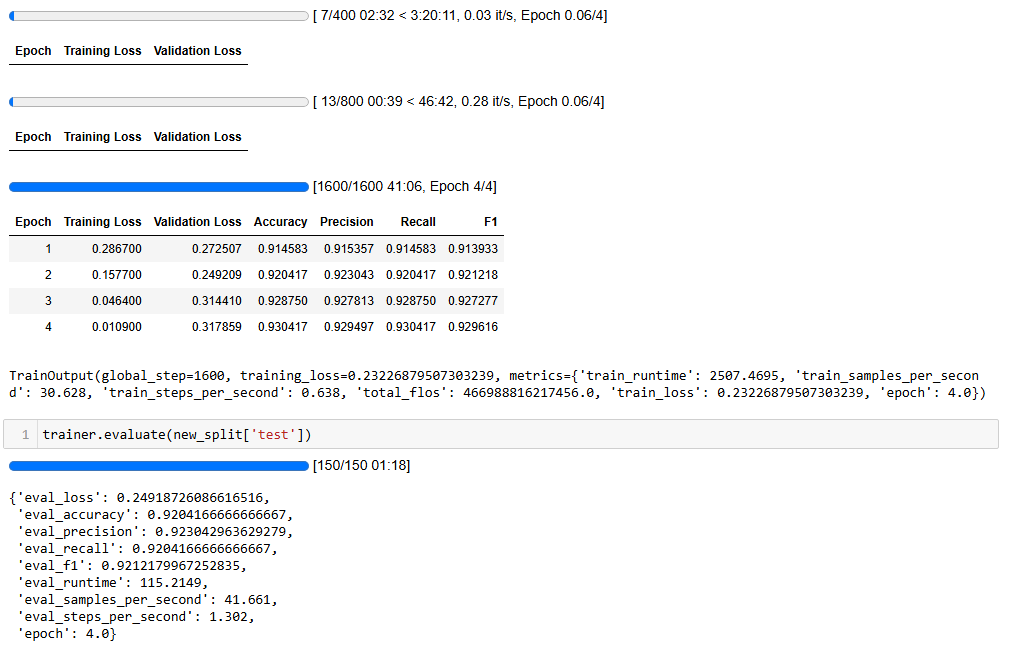

In [31]:
unique_rows

,label,url,title,text,topic,tags,date
0,0,https://lenta.ru/news/2023/09/10/biden_rocket/,Легкомоторный самолет атаковал вышку сотовой с...,10 сентября в 9:00 мск легкомоторный самолет ...,Россия,Происшествия,2023-09-10
1,1,https://lenta.ru/news/2023/07/21/bidddden/,ОСАГО можно будет оформить на день или месяц,В Госдуме в третьем чтении приняли законопрое...,Экономика,Деловой климат,2023-07-21
2,2,https://lenta.ru/news/2023/04/03/posobniki/,Военкор Татарский назвал вручившую ему статуэт...,Военный корреспондент Владлен Татарский (наст...,Силовые структуры,Следствие и суд,2023-04-03
3,3,https://lenta.ru/news/2023/07/01/otrazh/,Спасение бойцами «Отважных» раненного под Крем...,Бойцы группировки Вооруженных сил России «О» ...,Бывший СССР,Украина,2023-07-01
4,4,https://lenta.ru/news/2021/05/22/ne_propustit/,Россиянин отправил американца в больницу силов...,\n#ALLCAPS Dmitry Orlov hit on #NHLBruins Keva...,Спорт,Хоккей,2021-05-22
5,5,https://lenta.ru/news/2023/08/10/fedor/,101-летняя женщина поделилась секретами долгол...,"101-летняя жительница Огайо, США, Джейн Бернс ...",Забота о себе,Уход за собой,2023-08-10
6,7,https://lenta.ru/news/2021/11/24/ozon/,С трудом устоявшего на ногах пьяного москвича ...,"Москвича, который с трудом устоял на ногах пр...",Путешествия,Россия,2021-11-24
7,8,https://lenta.ru/news/2022/04/14/ill/,Учебные пуски «Калибров» с российских подлодок...,Две дизель-электрические подводные лодки Тихо...,Наука и техника,Оружие,2022-04-14


In [32]:
text = []
for i in unique_rows["text"]:
    text.append(i)

In [33]:
from transformers import pipeline

classifier = pipeline("text-classification", model=trainer.model.cpu(), tokenizer=tokenizer)
classifier(text)

Device set to use cuda:0


[{'label': 'Россия', 'score': 0.9980964064598083},
 {'label': 'Экономика', 'score': 0.7130624651908875},
 {'label': 'Силовые структуры', 'score': 0.9978266358375549},
 {'label': 'Россия', 'score': 0.9839017987251282},
 {'label': 'Спорт', 'score': 0.9983780384063721},
 {'label': 'Забота о себе', 'score': 0.9984657764434814},
 {'label': 'Путешествия', 'score': 0.9941552877426147},
 {'label': 'Наука и техника', 'score': 0.9981154203414917}]